In [1]:
import textwrap

import faceted
import numpy as np
import pandas as pd
import wandb
import xarray as xr

import plotting
import utils

In [2]:
TEMPLATE = "2026-09-09-{model}-ramped-sst-{climate}-random-perturbation-ic_0003-evaluator"

WANDB_RUNS = {
    "ACE2-SOM": {
        "1xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="published-baseline-rs3", climate="1xCO2")),
        "2xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="published-baseline-rs3", climate="2xCO2")),
        "4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="published-baseline-rs3", climate="4xCO2")),
    },
    "no-random-co2-energy-conserving-rs0": {
        "1xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs0", climate="1xCO2")),
        "2xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs0", climate="2xCO2")),
        "4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs0", climate="4xCO2")),
    },
    "no-random-co2-energy-conserving-rs1": {
        "1xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs1", climate="1xCO2")),
        "2xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs1", climate="2xCO2")),
        "4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="no-random-co2-energy-conserving-rs1", climate="4xCO2")),
    },
    "full-energy-conserving-rs0": {
        "1xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0", climate="1xCO2")),
        "2xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0", climate="2xCO2")),
        "4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0", climate="4xCO2")),
    },
    "full-energy-conserving-rs1": {
        "1xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1", climate="1xCO2")),
        "2xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1", climate="2xCO2")),
        "4xCO2": utils.wandb_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1", climate="4xCO2")),
    },
}

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/spencerc/.netrc.


In [3]:
def load_global_mean_metrics(wandb_run, variables, metric):
    pattern = "inference/mean/{metric}/{variable}"
    keys = [pattern.format(metric=metric, variable=variable) for variable in variables]
    metrics = pd.DataFrame(wandb_run.scan_history(keys=keys))

    metrics["time"] = pd.date_range(
        "2019-10-01T06", periods=len(metrics.index), freq="6h"
    )
    metrics = metrics.set_index("time")
    ds = xr.Dataset.from_dataframe(metrics)
    ds = ds.rename({pattern.format(metric=metric, variable=v): v for v in variables})
    return ds


def load_time_series_data(cases, variables, metric):
    api = wandb.Api()
    datasets = {}

    for model, runs in cases.items():
        for climate, run_id in runs.items():
            wandb_run = api.run(run_id)
            ds = load_global_mean_metrics(wandb_run, variables, metric)
            datasets[model, climate] = ds
    
    index = pd.MultiIndex.from_tuples(
        datasets.keys(), names=("model", "climate")
    )
    combined = xr.concat(datasets.values(), dim="case")
    return combined.assign_coords(case=index).unstack("case")

In [4]:
gen_ds = load_time_series_data(WANDB_RUNS, ["TMP2m", "air_temperature_0"], "weighted_mean_gen")
target_ds = load_time_series_data(WANDB_RUNS, ["TMP2m", "air_temperature_0"], "weighted_mean_target")

gen_ds = gen_ds.sel(time=slice("2020-01-01", "2025-01-01"))
target_ds = target_ds.sel(time=slice("2020-01-01", "2025-01-01"))

co2 = 1e6 * xr.open_zarr("gs://vcm-ml-raw-flexible-retention/2025-08-22-C96-SHiELD/regridded-zarrs/gaussian_grid_180_by_360/ramped-sst-4xCO2-random-perturbation-ic_0003/scalar.zarr").global_mean_co2.sel(time=slice("2020-01-01", "2025-01-01"))

/tmp/ipykernel_53410/1671290256.py:29: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'case' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return combined.assign_coords(case=index).unstack("case")
/tmp/ipykernel_53410/1671290256.py:29: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'case' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordina

In [5]:
print(gen_ds.isnull().to_array().any())
print(target_ds.isnull().to_array().any())

<xarray.DataArray ()> Size: 1B
array(False)
<xarray.DataArray ()> Size: 1B
array(False)


In [6]:
COLORS = {
    "ACE2-SOM": "C3",
    "no-random-co2-energy-conserving-rs0": "C2",
    "full-energy-conserving-rs0": "C4",
}
ALTERNATE_MODELS = {
    "full-energy-conserving-rs0": "full-energy-conserving-rs1",
    "no-random-co2-energy-conserving-rs0": "no-random-co2-energy-conserving-rs1"
}

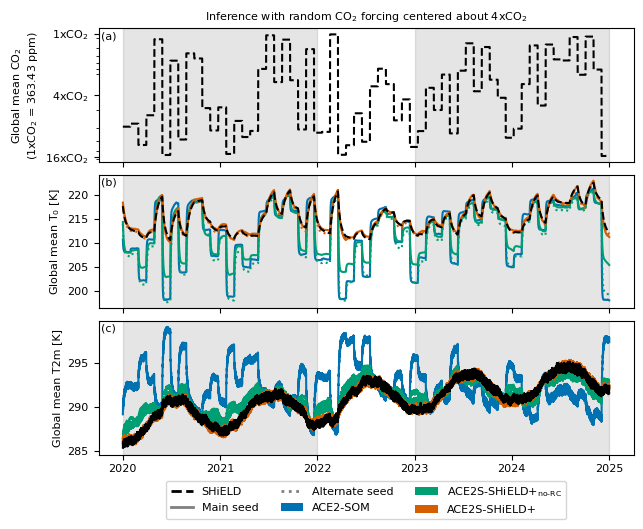

In [7]:
plotting.configure_style()

fig, (ax1, ax2, ax3) = faceted.faceted(3, 1, width=6.5, aspect=0.25, sharey=False, internal_pad=0.125, left_pad=0.9, bottom_pad=0.7)

co2.plot(ax=ax1, yscale="log", yincrease=False, color="k", ls="--")
ax1.set_yticks([363.43, 4 * 363.43, 16 * 363.43])
ax1.set_yticklabels(["1xCO$_2$", "4xCO$_2$", "16xCO$_2$"])

for model, color in COLORS.items():
    gen_ds.sel(model=model, climate="4xCO2").air_temperature_0.plot(ax=ax2, color=color)
    if model in ALTERNATE_MODELS:
        gen_ds.sel(model=ALTERNATE_MODELS[model], climate="4xCO2").air_temperature_0.plot(ax=ax2, color=color, ls=":")
target_ds.sel(model=model, climate="4xCO2").air_temperature_0.plot(ax=ax2, color="k", ls="--")

for model, color in COLORS.items():
    gen_ds.sel(model=model, climate="4xCO2").TMP2m.plot(ax=ax3, color=color)
    if model in ALTERNATE_MODELS:
        gen_ds.sel(model=ALTERNATE_MODELS[model], climate="4xCO2").TMP2m.plot(ax=ax3, color=color, ls=":")
target_ds.sel(model=model, climate="4xCO2").TMP2m.plot(ax=ax3, color="k", ls="--")

for ax in (ax1, ax2, ax3):
    ax.set_title("")
    ax.set_xlabel("")

ax1.set_ylabel(textwrap.fill("Global mean CO$_2$ (1xCO$_2$ = 363.43 ppm)", width=25))
ax2.set_ylabel(textwrap.fill("Global mean T$_0$ [K]", width=25))
ax3.set_ylabel(textwrap.fill("Global mean T2m [K]", width=25))

ax1.set_title("Inference with random CO$_2$ forcing centered about 4xCO$_2$")

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color="k", ls="--", label="SHiELD"),
    Line2D([0], [0], color="gray", ls=":", label="Alternate seed"),
    Line2D([0], [0], color=COLORS["ACE2-SOM"], ls="-", label="ACE2-SOM"),
    Line2D([0], [0], color=COLORS["no-random-co2-energy-conserving-rs0"], ls="-", label="ACE2S-SHiELD+$_{\\text{no-RC}}$"),
    Line2D([0], [0], color=COLORS["full-energy-conserving-rs0"], ls="-", label="ACE2S-SHiELD+"),
]

for ax in (ax1, ax2, ax3):
    ax.axvspan(np.datetime64("2020-01-01"), np.datetime64("2022-01-01"), color="k", alpha=0.1)
    ax.axvspan(np.datetime64("2023-01-01"), np.datetime64("2025-01-01"), color="k", alpha=0.1)
from matplotlib.patches import Patch

span_patch = Patch(color="k", alpha=0.1, label="Held out from training/validation")
legend_handles.insert(1, span_patch)

line_data = {
    "SHiELD": ("k", "--"),
    "Main seed": ("gray", "-"),
    "Alternate seed": ("gray", ":"),
}
from matplotlib.lines import Line2D
lines = [Line2D([0], [0], color=color, linestyle=ls, lw=2) for color, ls in line_data.values()]

patch_colors = {
    "ACE2-SOM": ("C3", 1.0),
    "ACE2S-SHiELD+$_{\\text{no-RC}}$": ("C2", 1.0),
    "ACE2S-SHiELD+": ("C4", 1.0),
}
from matplotlib.patches import Patch
patches = [
    Patch(facecolor=color, label=label, edgecolor='none', alpha=alpha)
    for label, (color, alpha) in patch_colors.items()
]

central_x_position = plotting.get_central_position_between_axes((ax1, ax2, ax3), "x")
fig.legend(lines + patches, list(line_data.keys()) + list(patch_colors.keys()), loc="lower center", bbox_to_anchor=(central_x_position, 0.0), ncol=3, fontsize=8)

for ax, label in zip((ax1, ax2, ax3), ("a", "b", "c")):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

fig.patch.set_alpha(0.0)
fig.savefig("figure-08.png", dpi=300)
fig.savefig("figure-08.pdf")